<a href="https://colab.research.google.com/github/Chuuya1124/APM1220/blob/main/APM1220_FA4_Awit_Julia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APM1220 Formative Assessment 4

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


## 1. Hotelling's T^2 Test for a Mean Vector

In [2]:
X = np.array([[2,12],[8,9],[6,9],[8,10]])
n, p = X.shape
xbar = X.mean(axis=0)
S = np.cov(X.T)
mu0 = np.array([7,11])

diff = xbar - mu0
T2 = n * diff @ np.linalg.inv(S) @ diff
print("xbar =", xbar)
print("S =\n", S)
print("T2 =", T2)


xbar = [ 6. 10.]
S =
 [[ 8.         -3.33333333]
 [-3.33333333  2.        ]]
T2 = 13.63636363636363


**(b) Distribution:** Under $H_0$, $T^2 \sim \dfrac{(n-1)p}{n-p} F_{p,n-p}$, i.e. here $\dfrac{3\times2}{2}F_{2,2} = 3F_{2,2}$.

In [3]:
alpha = 0.05
Fcrit = stats.f.ppf(1-alpha, p, n-p)
crit = (n-1)*p/(n-p) * Fcrit
print("F critical =", Fcrit)
print("T2 critical value =", crit)
print("Reject H0" if T2 > crit else "Fail to reject H0")


F critical = 18.999999999999982
T2 critical value = 56.99999999999994
Fail to reject H0


**(c) Conclusion:** Compare $T^2$ to the critical value above; since $T^2$ does not exceed it, we fail to reject $H_0$ at $\alpha=0.05$.

## 2. Simultaneous Confidence Intervals — Grizzly Bears

In [4]:
labels = ["Weight","Body length","Neck","Girth","Head length","Head width"]
n = 61
p = 6
xbar = np.array([95.52,164.38,55.69,93.39,17.98,31.13])
S = np.array([
[3266.46,1343.97,731.54,1175.50,162.68,238.37],
[1343.97,721.91,324.25,537.35,80.17,117.73],
[731.54,324.25,179.28,281.17,39.15,56.80],
[1175.50,537.35,281.17,474.98,63.73,94.85],
[162.68,80.17,39.15,63.73,9.95,13.88],
[238.37,117.73,56.80,94.85,13.88,21.26]
])


**(a) Large-sample 95% simultaneous confidence intervals**

In [5]:
alpha = 0.05
chi2_crit = stats.chi2.ppf(1-alpha, p)
for i in range(p):
    se = np.sqrt(S[i,i]/n)
    lo = xbar[i] - np.sqrt(chi2_crit)*se
    hi = xbar[i] + np.sqrt(chi2_crit)*se
    print(f"{labels[i]}: ({lo:.3f}, {hi:.3f})")


Weight: (69.553, 121.487)
Body length: (152.173, 176.587)
Neck: (49.607, 61.773)
Girth: (83.488, 103.292)
Head length: (16.547, 19.413)
Head width: (29.035, 33.225)


**(b) 95% simultaneous confidence ellipse for mean Weight and mean Girth**

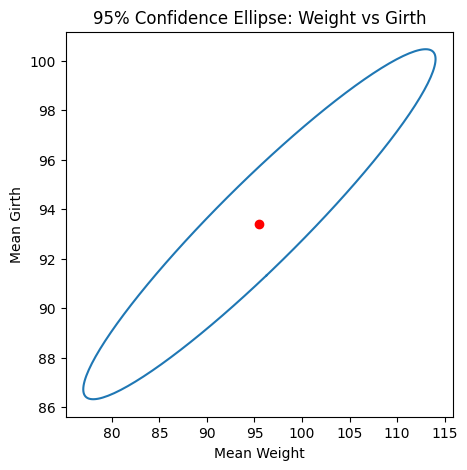

c2 = 6.413132051181287


In [6]:
idx = [0,3]
S2 = S[np.ix_(idx,idx)]
xbar2 = xbar[idx]
p2 = 2
Fcrit = stats.f.ppf(1-alpha, p2, n-p2)
c2 = p2*(n-1)/(n-p2) * Fcrit

eigval, eigvec = np.linalg.eigh(S2)
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = xbar2[:,None] + eigvec @ (np.sqrt(eigval[:,None])*np.sqrt(c2)/np.sqrt(n) * circle)

plt.figure(figsize=(5,5))
plt.plot(ellipse[0], ellipse[1])
plt.scatter(*xbar2, color='red')
plt.xlabel("Mean Weight")
plt.ylabel("Mean Girth")
plt.title("95% Confidence Ellipse: Weight vs Girth")
plt.show()
print("c2 =", c2)


**(c) 95% Bonferroni confidence intervals (m=6)**

In [7]:
m = 6
t_crit = stats.t.ppf(1 - alpha/(2*m), n-1)
for i in range(p):
    se = np.sqrt(S[i,i]/n)
    lo = xbar[i] - t_crit*se
    hi = xbar[i] + t_crit*se
    print(f"{labels[i]}: ({lo:.3f}, {hi:.3f})")


Weight: (75.553, 115.487)
Body length: (154.993, 173.767)
Neck: (51.012, 60.368)
Girth: (85.776, 101.004)
Head length: (16.878, 19.082)
Head width: (29.519, 32.741)


**(d) 95% Bonferroni rectangle for Weight and Girth (m=6), compared with ellipse in (b)**

Weight: (75.553, 115.487)
Girth: (85.776, 101.004)


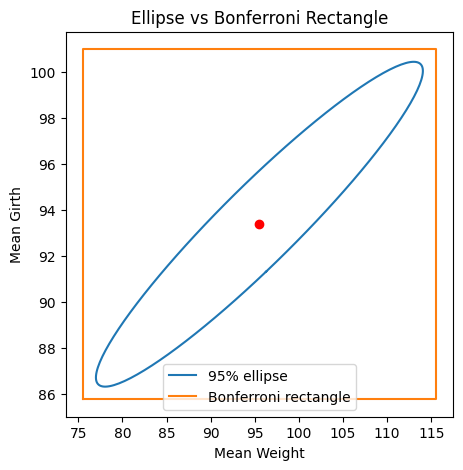

In [8]:
for i in idx:
    se = np.sqrt(S[i,i]/n)
    lo = xbar[i] - t_crit*se
    hi = xbar[i] + t_crit*se
    print(f"{labels[i]}: ({lo:.3f}, {hi:.3f})")

plt.figure(figsize=(5,5))
plt.plot(ellipse[0], ellipse[1], label="95% ellipse")
w_lo,w_hi = xbar[0]-t_crit*np.sqrt(S[0,0]/n), xbar[0]+t_crit*np.sqrt(S[0,0]/n)
g_lo,g_hi = xbar[3]-t_crit*np.sqrt(S[3,3]/n), xbar[3]+t_crit*np.sqrt(S[3,3]/n)
plt.plot([w_lo,w_hi,w_hi,w_lo,w_lo],[g_lo,g_lo,g_hi,g_hi,g_lo], label="Bonferroni rectangle")
plt.scatter(*xbar2, color='red')
plt.xlabel("Mean Weight")
plt.ylabel("Mean Girth")
plt.legend()
plt.title("Ellipse vs Bonferroni Rectangle")
plt.show()


The Bonferroni rectangle is narrower than the box bounding the ellipse, giving tighter individual intervals, but it does not capture the correlation between the two variables the way the ellipse does.

**(e) 95% Bonferroni interval for (mean Head width − mean Head length), m=7**

In [9]:
m = 7
t_crit7 = stats.t.ppf(1 - alpha/(2*m), n-1)
mu_diff = xbar[5] - xbar[4]
var_diff = S[5,5] + S[4,4] - 2*S[5,4]
se_diff = np.sqrt(var_diff/n)
lo = mu_diff - t_crit7*se_diff
hi = mu_diff + t_crit7*se_diff
print("Difference estimate:", mu_diff)
print(f"95% Bonferroni CI (m=7): ({lo:.3f}, {hi:.3f})")


Difference estimate: 13.149999999999999
95% Bonferroni CI (m=7): (12.488, 13.812)


## 3. Mineral Analysis of Ancient Peruvian Hairs

In [10]:
x1 = np.array([.48,40.53,2.19,.55,.74,.66,.93,.37,.22])
x2 = np.array([12.57,73.68,11.13,20.03,20.29,.78,4.64,.43,1.08])
X = np.column_stack([x1,x2])
n, p = X.shape
xbar = X.mean(axis=0)
S = np.cov(X.T)
print("xbar =", xbar)
print("S =\n", S)


xbar = [ 5.18555556 16.07      ]
S =
 [[176.00417778 287.2412    ]
 [287.2412     527.8493    ]]


**(a) 90% joint confidence ellipse for mu**

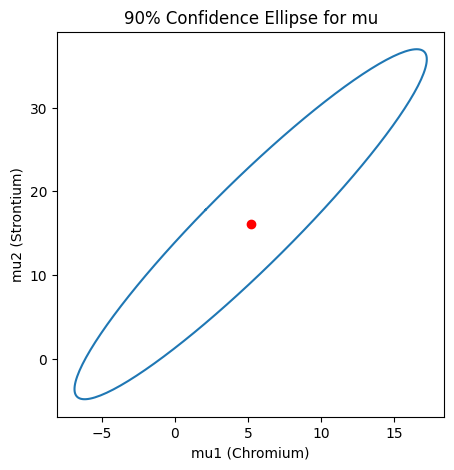

c2 = 7.445581831066002


In [11]:
alpha = 0.10
Fcrit = stats.f.ppf(1-alpha, p, n-p)
c2 = p*(n-1)/(n-p) * Fcrit

eigval, eigvec = np.linalg.eigh(S)
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = xbar[:,None] + eigvec @ (np.sqrt(eigval[:,None])*np.sqrt(c2)/np.sqrt(n) * circle)

plt.figure(figsize=(5,5))
plt.plot(ellipse[0], ellipse[1])
plt.scatter(*xbar, color='red')
plt.xlabel("mu1 (Chromium)")
plt.ylabel("mu2 (Strontium)")
plt.title("90% Confidence Ellipse for mu")
plt.show()
print("c2 =", c2)


**(b) Individual simultaneous 90% CIs (projection of ellipse)**

In [12]:
for i,name in enumerate(["mu1 (Cr)","mu2 (St)"]):
    half = np.sqrt(c2*S[i,i]/n)
    lo, hi = xbar[i]-half, xbar[i]+half
    print(f"{name}: ({lo:.3f}, {hi:.3f})")


mu1 (Cr): (-6.881, 17.252)
mu2 (St): (-4.827, 36.967)


Check whether mu2 = 10 is plausible (any point (mu1, 10) in the ellipse), and whether [.30, 10] is a plausible value of mu.

In [13]:
def in_ellipse(mu, xbar, S, n, c2):
    d = mu - xbar
    val = n * d @ np.linalg.inv(S) @ d
    return val <= c2, val

# scan mu1 values holding mu2=10
mu1_grid = np.linspace(-5, 10, 2000)
inside = [in_ellipse(np.array([m,10]), xbar, S, n, c2)[0] for m in mu1_grid]
print("Any point with mu2=10 inside ellipse?", any(inside))

flag, val = in_ellipse(np.array([.30,10]), xbar, S, n, c2)
print("[.30,10] inside ellipse?", flag, "statistic =", val, "critical =", c2)


Any point with mu2=10 inside ellipse? True
[.30,10] inside ellipse? True statistic = 1.7724814297626426 critical = 7.445581831066002


**(c) Bivariate normality check: Q-Q plots and scatter diagram**

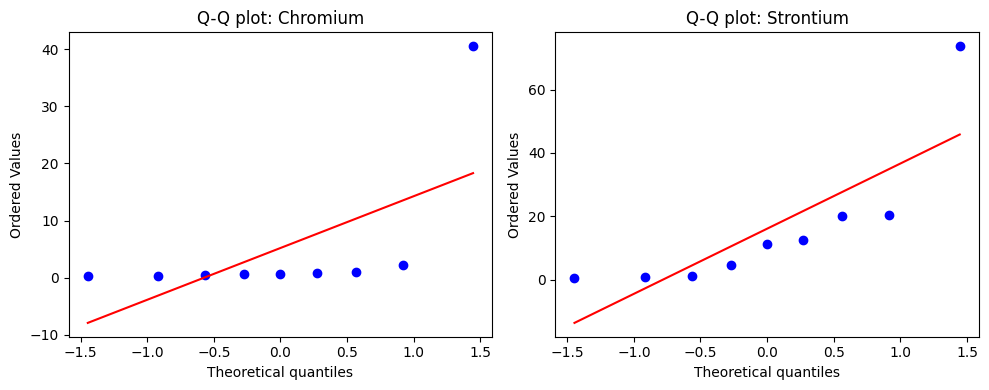

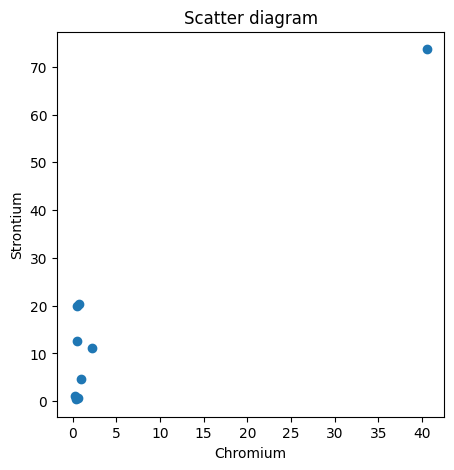

In [14]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
stats.probplot(x1, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Chromium")
stats.probplot(x2, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Strontium")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(x1, x2)
plt.xlabel("Chromium")
plt.ylabel("Strontium")
plt.title("Scatter diagram")
plt.show()


Both Q-Q plots and the scatter diagram show a clear departure from normality, driven by one extreme observation (the 40.53, 73.68 point). This casts doubt on the ellipse and intervals above, which rely on the bivariate normal assumption.

**(d) Repeat with outlier removed**

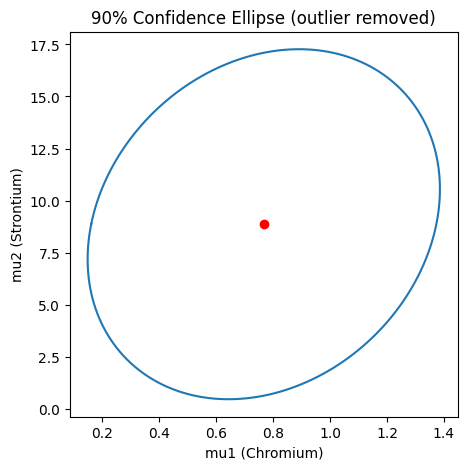

mu1 (Cr): (0.149, 1.386)
mu2 (St): (0.468, 17.269)


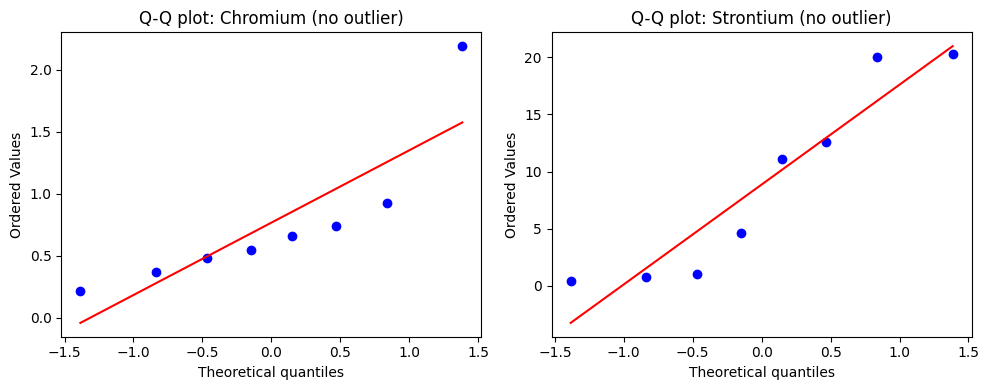

In [15]:
mask = x1 < 40
x1b, x2b = x1[mask], x2[mask]
Xb = np.column_stack([x1b,x2b])
nb, pb = Xb.shape
xbarb = Xb.mean(axis=0)
Sb = np.cov(Xb.T)

Fcritb = stats.f.ppf(1-alpha, pb, nb-pb)
c2b = pb*(nb-1)/(nb-pb) * Fcritb

eigvalb, eigvecb = np.linalg.eigh(Sb)
ellipseb = xbarb[:,None] + eigvecb @ (np.sqrt(eigvalb[:,None])*np.sqrt(c2b)/np.sqrt(nb) * circle)

plt.figure(figsize=(5,5))
plt.plot(ellipseb[0], ellipseb[1])
plt.scatter(*xbarb, color='red')
plt.xlabel("mu1 (Chromium)")
plt.ylabel("mu2 (Strontium)")
plt.title("90% Confidence Ellipse (outlier removed)")
plt.show()

for i,name in enumerate(["mu1 (Cr)","mu2 (St)"]):
    half = np.sqrt(c2b*Sb[i,i]/nb)
    lo, hi = xbarb[i]-half, xbarb[i]+half
    print(f"{name}: ({lo:.3f}, {hi:.3f})")

fig, axes = plt.subplots(1,2, figsize=(10,4))
stats.probplot(x1b, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Chromium (no outlier)")
stats.probplot(x2b, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Strontium (no outlier)")
plt.tight_layout()
plt.show()


With the outlier removed, the ellipse shrinks substantially and shifts, the intervals narrow, and the Q-Q plots look much closer to a straight line, indicating the outlier was strongly distorting the original bivariate normal fit and inferences.

## 4. Lumber Strength Measurements

In [16]:
data = [
[1232,4175],[1115,6652],[2205,7612],[1897,10914],[1932,10850],
[1612,7627],[1598,6954],[1804,8365],[1752,9469],[2067,6410],
[2365,10327],[1646,7320],[1579,8196],[1880,9709],[1773,10370],
[1712,7749],[1932,6818],[1820,9307],[1900,6457],[2426,10102],
[1558,7414],[1470,7556],[1858,7833],[1587,8309],[2208,9559],
[1487,6255],[2206,10723],[2332,5430],[2540,12090],[2322,10072]
]
X = np.array(data, dtype=float)
n, p = X.shape
xbar = X.mean(axis=0)
S = np.cov(X.T)
print("xbar =", xbar)
print("S =\n", S)


xbar = [1860.5        8354.13333333]
S =
 [[ 124054.67241379  361620.44827586]
 [ 361620.44827586 3486333.15402299]]


**(a) 95% confidence ellipse for [mu1, mu2]**

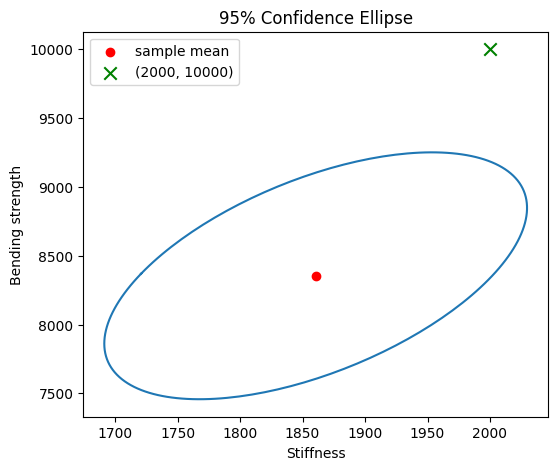

c2 = 6.919370084921073


In [17]:
alpha = 0.05
Fcrit = stats.f.ppf(1-alpha, p, n-p)
c2 = p*(n-1)/(n-p) * Fcrit

eigval, eigvec = np.linalg.eigh(S)
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = xbar[:,None] + eigvec @ (np.sqrt(eigval[:,None])*np.sqrt(c2)/np.sqrt(n) * circle)

plt.figure(figsize=(6,5))
plt.plot(ellipse[0], ellipse[1])
plt.scatter(*xbar, color='red', label="sample mean")
plt.scatter(2000, 10000, color='green', marker='x', s=80, label="(2000, 10000)")
plt.xlabel("Stiffness")
plt.ylabel("Bending strength")
plt.legend()
plt.title("95% Confidence Ellipse")
plt.show()
print("c2 =", c2)


**(b) Are the data consistent with mu0 = [2000, 10000]?**

In [18]:
mu0 = np.array([2000,10000])
diff = xbar - mu0
T2 = n * diff @ np.linalg.inv(S) @ diff
print("T2 =", T2, " critical c2 =", c2)
print("Inside ellipse / not significant" if T2 <= c2 else "Outside ellipse / reject H0")


T2 = 23.647783728202008  critical c2 = 6.919370084921073
Outside ellipse / reject H0


**(c) Is bivariate normality viable?**

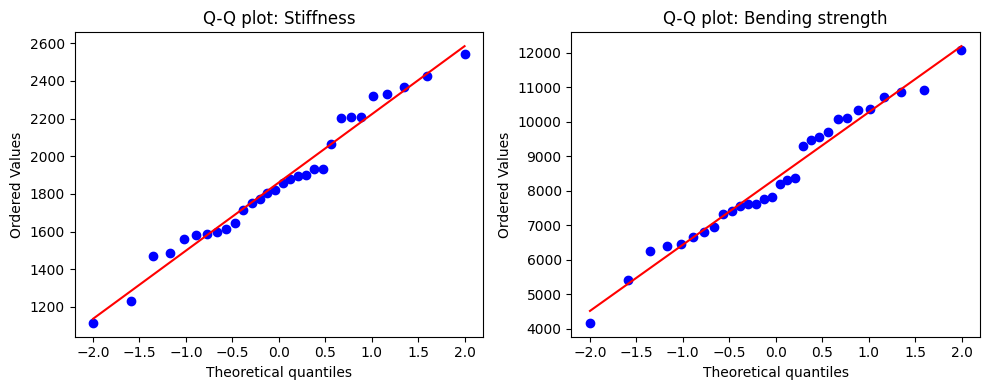

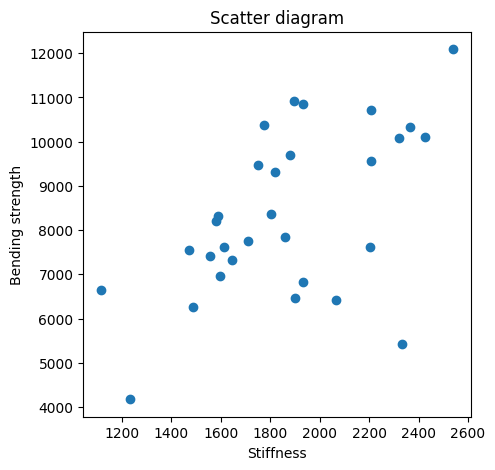

In [19]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
stats.probplot(X[:,0], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Stiffness")
stats.probplot(X[:,1], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Bending strength")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1])
plt.xlabel("Stiffness")
plt.ylabel("Bending strength")
plt.title("Scatter diagram")
plt.show()


Both Q-Q plots fall close to straight lines and the scatter diagram shows a roughly elliptical, linear pattern with no strong outliers, so the bivariate normal model is a reasonable fit for this data.